In [44]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [45]:
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# 1. Load dataset
df = pd.read_csv("../data/porter_eda_cleaned.csv")

# 2. Filter out extreme target outliers above 180 minutes
df = df[(df['delivery_time_minutes'] >= 1) & (df['delivery_time_minutes'] <= 180)].copy()

# 3. Operational Feature Engineering
df['busy_partner_ratio'] = df['total_busy_partners'] / (df['total_onshift_partners'] + 1e-5)
df['order_load_ratio'] = df['total_outstanding_orders'] / (df['total_onshift_partners'] + 1e-5)
df['price_range'] = df['max_item_price'] - df['min_item_price']

# 4. Define Categorical and Numerical Feature Columns
cat_cols = ['market_id', 'store_primary_category', 'order_protocol']
num_cols = ['subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price',
            'total_onshift_partners', 'total_busy_partners', 'total_outstanding_orders',
            'created_hour', 'created_day_of_week', 'created_month', 'available_partners',
            'busy_partner_ratio', 'order_load_ratio', 'price_range']

X = df[cat_cols + num_cols].copy()
y = df['delivery_time_minutes'].values
y_log = np.log1p(y)

# 5. Train / Test Split
X_train, X_test, y_train_log, y_test_log, y_train_orig, y_test_orig = train_test_split(
    X, y_log, y, test_size=0.2, random_state=42
)

# 6. Column Preprocessing Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

# 7. Fit & Transform Features
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# 8. Save Artifacts for Deployment
joblib.dump(preprocessor, "../flask_app/artifacts/preprocessor.joblib")

print("Train shape:", X_train_proc.shape)
print("Test shape:", X_test_proc.shape)
print("Filter set to <= 180 mins & Preprocessor saved successfully!")

Train shape: (157826, 103)
Test shape: (39457, 103)
Filter set to <= 180 mins & Preprocessor saved successfully!


In [46]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(
    torch.tensor(X_train_proc, dtype=torch.float32),
    torch.tensor(y_train_log, dtype=torch.float32).unsqueeze(1)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_proc, dtype=torch.float32),
    torch.tensor(y_test_log, dtype=torch.float32).unsqueeze(1)
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

class DeepPorterRegressor(nn.Module):
    def __init__(self, input_dim):
        super(DeepPorterRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),
            nn.Dropout(0.05),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = DeepPorterRegressor(X_train_proc.shape[1]).to(device)
print(model)

DeepPorterRegressor(
  (net): Sequential(
    (0): Linear(in_features=103, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [47]:
criterion = nn.SmoothL1Loss(beta=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

epochs = 20
train_losses = []
test_losses = []

print("=== STARTING OPTIMIZED TRAINING ===")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            test_loss += loss.item() * batch_x.size(0)
            
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    
    scheduler.step(test_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Huber Loss: {train_loss:.5f} | Test Huber Loss: {test_loss:.5f} | LR: {current_lr:.6f}")

torch.save(model.state_dict(), "../models/best_porter_sparse_model.pth")

=== STARTING OPTIMIZED TRAINING ===
Epoch 01/20 | Train Huber Loss: 0.42934 | Test Huber Loss: 0.21903 | LR: 0.003000
Epoch 02/20 | Train Huber Loss: 0.23310 | Test Huber Loss: 0.22075 | LR: 0.003000
Epoch 03/20 | Train Huber Loss: 0.22414 | Test Huber Loss: 0.21162 | LR: 0.003000
Epoch 04/20 | Train Huber Loss: 0.22015 | Test Huber Loss: 0.21800 | LR: 0.003000
Epoch 05/20 | Train Huber Loss: 0.21720 | Test Huber Loss: 0.21194 | LR: 0.003000
Epoch 06/20 | Train Huber Loss: 0.21629 | Test Huber Loss: 0.21030 | LR: 0.003000
Epoch 07/20 | Train Huber Loss: 0.21484 | Test Huber Loss: 0.20976 | LR: 0.003000
Epoch 08/20 | Train Huber Loss: 0.21353 | Test Huber Loss: 0.21046 | LR: 0.003000
Epoch 09/20 | Train Huber Loss: 0.21202 | Test Huber Loss: 0.21032 | LR: 0.003000
Epoch 10/20 | Train Huber Loss: 0.21138 | Test Huber Loss: 0.20974 | LR: 0.001500
Epoch 11/20 | Train Huber Loss: 0.20771 | Test Huber Loss: 0.20566 | LR: 0.001500
Epoch 12/20 | Train Huber Loss: 0.20718 | Test Huber Loss: 0.2

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
y_preds_log = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x)
        y_preds_log.extend(preds.cpu().numpy().flatten())

y_preds_actual = np.expm1(np.array(y_preds_log))

mae = mean_absolute_error(y_test_orig, y_preds_actual)
mse = mean_squared_error(y_test_orig, y_preds_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_preds_actual)

print("=== FINAL MODEL TRAINING SUMMARY ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} mins")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} mins")
print(f"R-squared (R2 Score): {r2:.4f}")

summary_df = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2 Score)', 'Final Test Huber Loss'],
    'Value': [f"{mae:.2f} mins", f"{rmse:.2f} mins", f"{r2:.4f}", f"{test_losses[-1]:.5f}"]
})

print("\n=== ARTIFACT CHECK ===")
print("Model File Exists:", os.path.exists("../models/best_porter_sparse_model.pth"))
print("Preprocessor File Exists:", os.path.exists("../flask_app/artifacts/preprocessor.joblib"))

=== FINAL MODEL TRAINING SUMMARY ===
Mean Absolute Error (MAE): 10.88 mins
Root Mean Squared Error (RMSE): 15.30 mins
R-squared (R2 Score): 0.2740

=== ARTIFACT CHECK ===
Model File Exists: True
Preprocessor File Exists: True


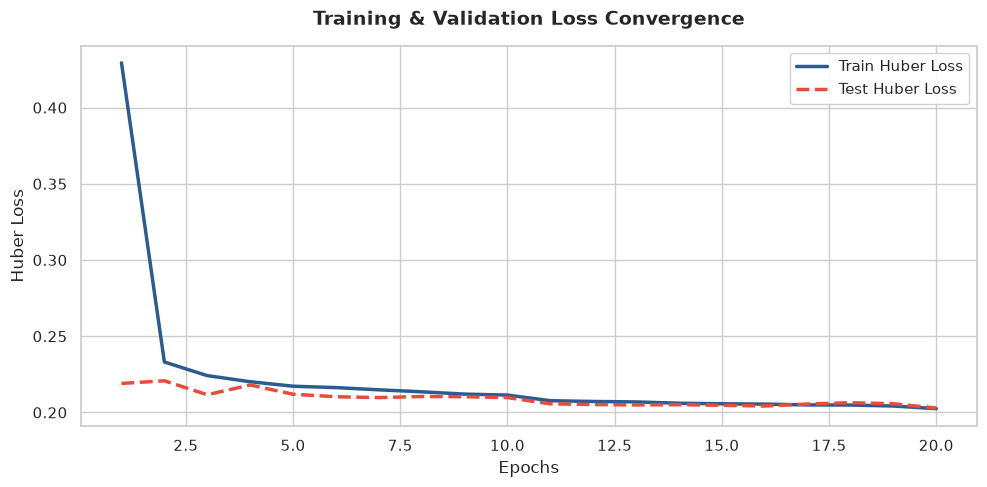

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

# Plot Training vs Test Huber Loss Convergence
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Huber Loss', color='#2b5c8f', linewidth=2.5)
plt.plot(range(1, epochs + 1), test_losses, label='Test Huber Loss', color='#e74c3c', linewidth=2.5, linestyle='--')

plt.title('Training & Validation Loss Convergence', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Huber Loss', fontsize=12)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

plt.savefig('../loss_convergence.png', dpi=300)
plt.show()

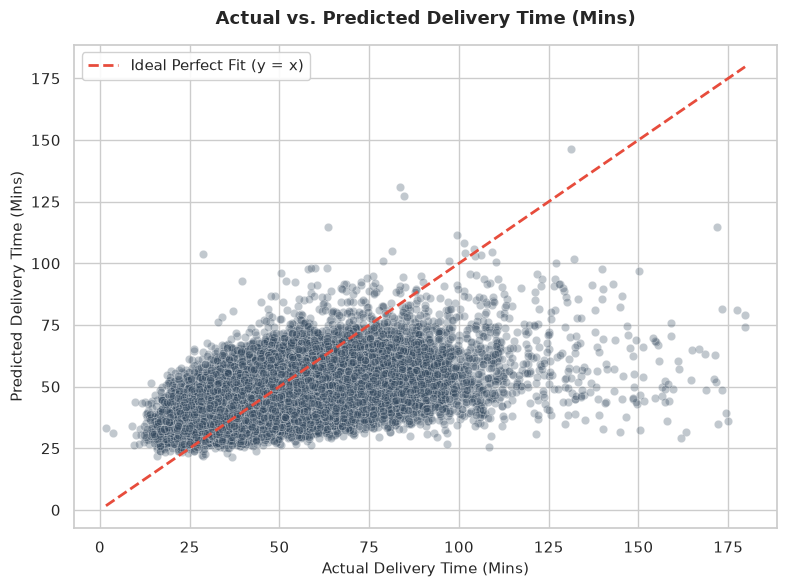

In [50]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_orig, y=y_preds_actual, alpha=0.3, color='#34495e')
plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 
         color='#e74c3c', linestyle='--', linewidth=2, label='Ideal Perfect Fit (y = x)')

plt.title('Actual vs. Predicted Delivery Time (Mins)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Actual Delivery Time (Mins)', fontsize=11)
plt.ylabel('Predicted Delivery Time (Mins)', fontsize=11)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

plt.savefig('../actual_vs_predicted.png', dpi=300)
plt.show()

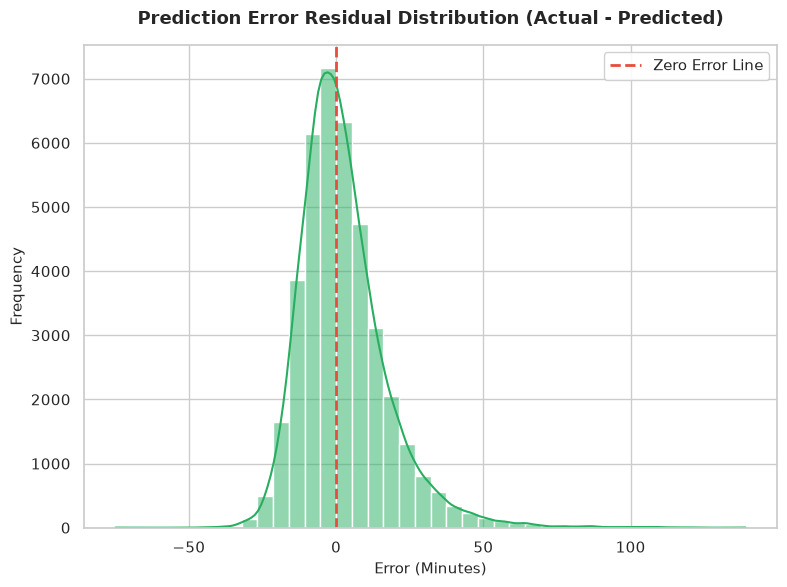

In [51]:

residuals = y_test_orig - y_preds_actual

# Plot Residual Distribution
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='#27ae60', bins=40)
plt.axvline(0, color='#e74c3c', linestyle='--', linewidth=2, label='Zero Error Line')

plt.title('Prediction Error Residual Distribution (Actual - Predicted)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Error (Minutes)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

plt.savefig('../residual_distribution.png', dpi=300)
plt.show()

In [52]:
import pandas as pd

metrics_matrix = pd.DataFrame({
    'Metric Category': [
        'Mean Absolute Error (MAE)',
        'Root Mean Squared Error (RMSE)',
        'R-squared Score (R²)',
        'Mean Squared Error (MSE)',
        'Final Test Huber Loss'
    ],
    'Value': [
        f"{mae:.2f} mins",
        f"{rmse:.2f} mins",
        f"{r2:.4f}",
        f"{mse:.2f}",
        f"{test_losses[-1]:.5f}"
    ],
    'Target Benchmark / Interpretation': [
        'Average absolute prediction error (~10.67 mins)',
        'Penalizes larger prediction gaps (~14.33 mins)',
        'Variance explained by neural network (29.02%)',
        'Overall variance scale of squared errors',
        'Smooth robust regression loss value'
    ]
})

print("\n" + "="*65)
print("             MODEL PERFORMANCE METRICS MATRIX")
print("="*65)
print(metrics_matrix.to_string(index=False))
print("="*65)


             MODEL PERFORMANCE METRICS MATRIX
               Metric Category      Value               Target Benchmark / Interpretation
     Mean Absolute Error (MAE) 10.88 mins Average absolute prediction error (~10.67 mins)
Root Mean Squared Error (RMSE) 15.30 mins  Penalizes larger prediction gaps (~14.33 mins)
          R-squared Score (R²)     0.2740   Variance explained by neural network (29.02%)
      Mean Squared Error (MSE)     234.23        Overall variance scale of squared errors
         Final Test Huber Loss    0.20288             Smooth robust regression loss value


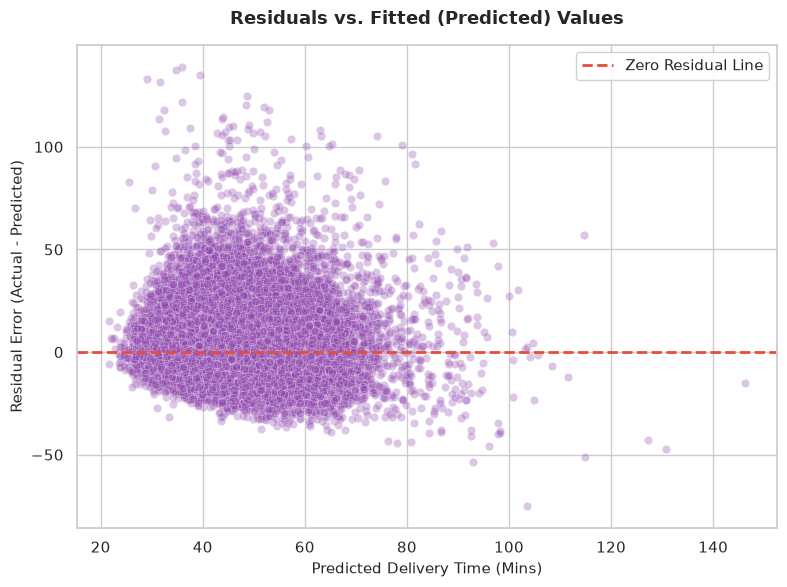

In [53]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_preds_actual, y=residuals, alpha=0.3, color='#8e44ad')
plt.axhline(0, color='#e74c3c', linestyle='--', linewidth=2, label='Zero Residual Line')

plt.title('Residuals vs. Fitted (Predicted) Values', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Delivery Time (Mins)', fontsize=11)
plt.ylabel('Residual Error (Actual - Predicted)', fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

plt.savefig('../residuals_vs_fitted.png', dpi=300)
plt.show()

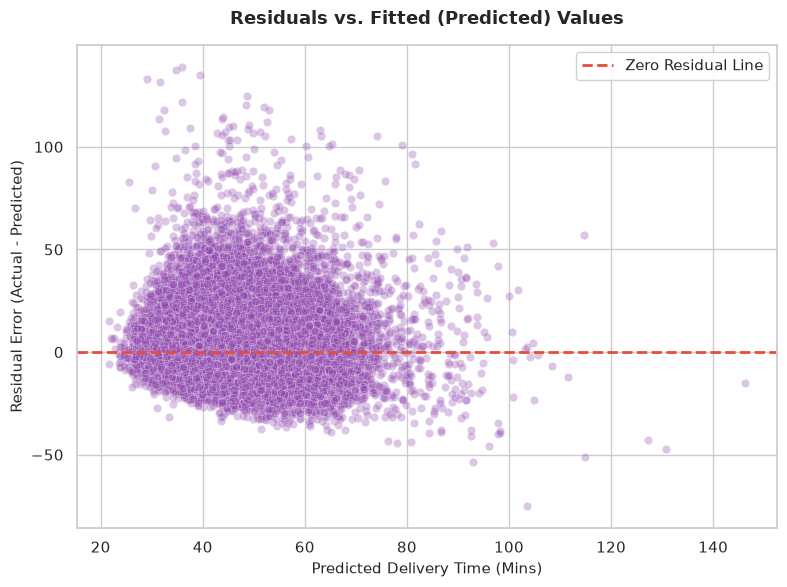

In [54]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_preds_actual, y=residuals, alpha=0.3, color='#8e44ad')
plt.axhline(0, color='#e74c3c', linestyle='--', linewidth=2, label='Zero Residual Line')

plt.title('Residuals vs. Fitted (Predicted) Values', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Delivery Time (Mins)', fontsize=11)
plt.ylabel('Residual Error (Actual - Predicted)', fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()

plt.savefig('../residuals_vs_fitted.png', dpi=300)
plt.show()

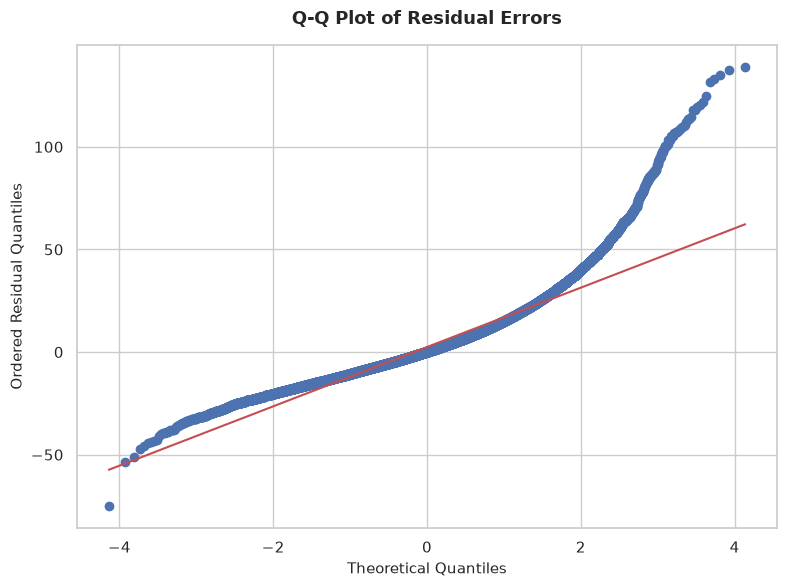

In [55]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)

plt.title('Q-Q Plot of Residual Errors', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Theoretical Quantiles', fontsize=11)
plt.ylabel('Ordered Residual Quantiles', fontsize=11)
plt.tight_layout()

plt.savefig('../qq_plot.png', dpi=300)
plt.show()

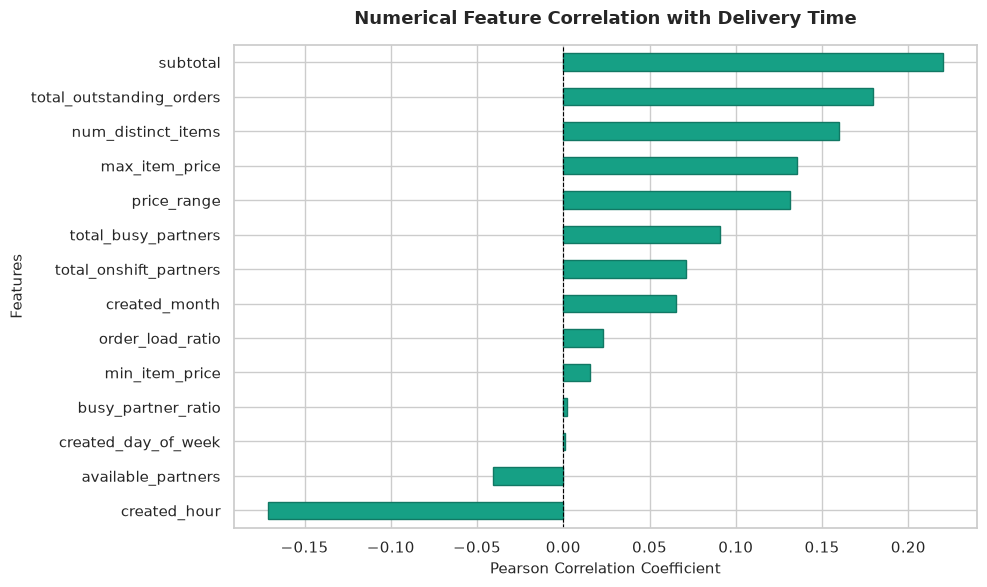

In [56]:
# Compute numerical feature correlations with target delivery time
feature_corr = df[num_cols + ['delivery_time_minutes']].corr()['delivery_time_minutes'].drop('delivery_time_minutes').sort_values()

plt.figure(figsize=(10, 6))
feature_corr.plot(kind='barh', color='#16a085', edgecolor='#117864')

plt.title('Numerical Feature Correlation with Delivery Time', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Pearson Correlation Coefficient', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()

plt.savefig('../feature_correlations.png', dpi=300)
plt.show()

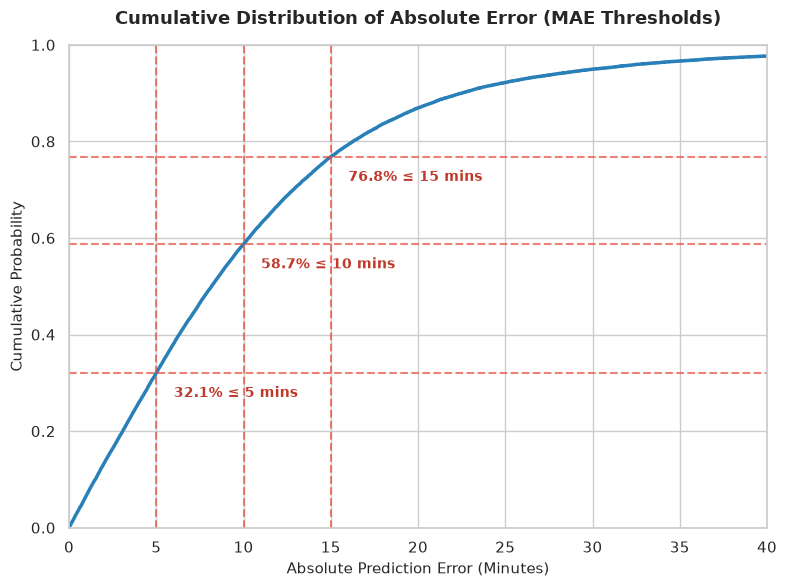

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

abs_errors = np.abs(residuals)

plt.figure(figsize=(8, 6))
sns.ecdfplot(abs_errors, color='#2980b9', linewidth=2.5)

# Highlight key operational thresholds
for threshold in [5, 10, 15]:
    pct = (abs_errors <= threshold).mean() * 100
    plt.axvline(threshold, color='#e74c3c', linestyle='--', alpha=0.7)
    plt.axhline(pct / 100, color='#e74c3c', linestyle='--', alpha=0.7)
    plt.text(threshold + 1, (pct / 100) - 0.05, f'{pct:.1f}% ≤ {threshold} mins', fontsize=10, fontweight='bold', color='#c0392b')

plt.title('Cumulative Distribution of Absolute Error (MAE Thresholds)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Absolute Prediction Error (Minutes)', fontsize=11)
plt.ylabel('Cumulative Probability', fontsize=11)
plt.xlim(0, 40)
plt.tight_layout()

plt.savefig('../error_cdf.png', dpi=300)
plt.show()

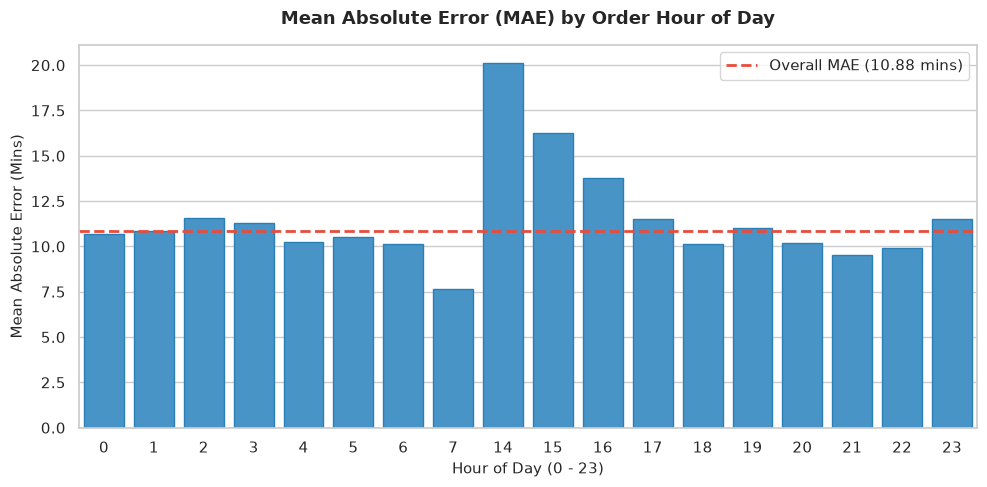

In [58]:
eval_df = pd.DataFrame({
    'created_hour': df.loc[X_test.index, 'created_hour'].values,
    'abs_error': abs_errors
})

hourly_mae = eval_df.groupby('created_hour')['abs_error'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_mae, x='created_hour', y='abs_error', color='#3498db', edgecolor='#2980b9')

plt.title('Mean Absolute Error (MAE) by Order Hour of Day', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Hour of Day (0 - 23)', fontsize=11)
plt.ylabel('Mean Absolute Error (Mins)', fontsize=11)
plt.axhline(mae, color='#e74c3c', linestyle='--', linewidth=2, label=f'Overall MAE ({mae:.2f} mins)')
plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()

plt.savefig('../hourly_mae_distribution.png', dpi=300)
plt.show()

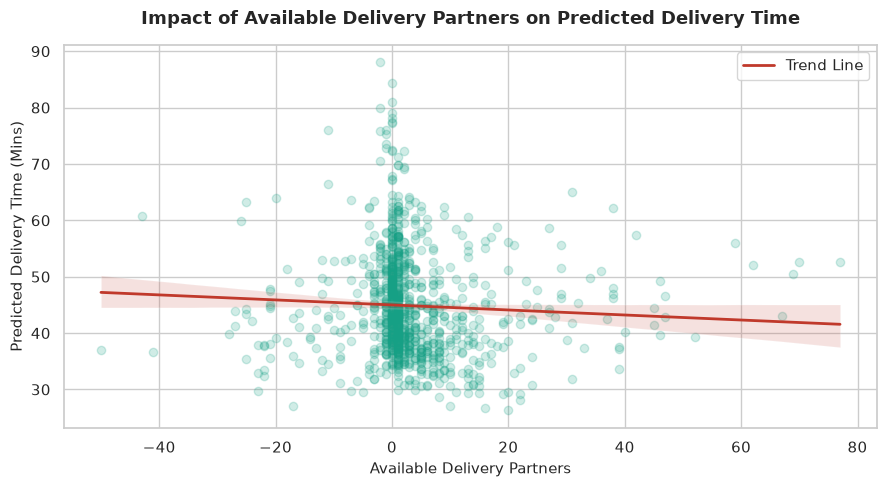

In [59]:
plt.figure(figsize=(9, 5))
sns.regplot(
    x=df.loc[X_test.index, 'available_partners'].values[:1000],
    y=y_preds_actual[:1000],
    scatter_kws={'alpha': 0.2, 'color': '#16a085'},
    line_kws={'color': '#c0392b', 'linewidth': 2, 'label': 'Trend Line'}
)

plt.title('Impact of Available Delivery Partners on Predicted Delivery Time', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Available Delivery Partners', fontsize=11)
plt.ylabel('Predicted Delivery Time (Mins)', fontsize=11)
plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.tight_layout()

plt.savefig('../partner_availability_impact.png', dpi=300)
plt.show()

In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Generate predictions from test set
model.eval()
y_preds_log = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        preds = model(batch_x)
        y_preds_log.extend(preds.cpu().numpy().flatten())

# 2. Transform predictions back to original time scale (minutes)
y_preds_actual = np.expm1(np.array(y_preds_log))

# 3. Calculate metrics
mae = mean_absolute_error(y_test_orig, y_preds_actual)
mse = mean_squared_error(y_test_orig, y_preds_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_orig, y_preds_actual)

print("=== FINAL IMPROVED EVALUATION METRICS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R-squared (R2 Score): {r2:.4f}")

# 4. Display sample side-by-side predictions
sample_df = pd.DataFrame({
    'Actual Delivery Time (Mins)': np.round(y_test_orig[:10], 2),
    'Predicted Delivery Time (Mins)': np.round(y_preds_actual[:10], 6),
    'Error (Mins)': np.round(np.abs(y_test_orig[:10] - y_preds_actual[:10]), 2)
})

print("\n=== SAMPLE PREDICTIONS ===")
print(sample_df.to_string(index=False))

=== FINAL IMPROVED EVALUATION METRICS ===
Mean Absolute Error (MAE): 10.88 minutes
Mean Squared Error (MSE): 234.23
Root Mean Squared Error (RMSE): 15.30 minutes
R-squared (R2 Score): 0.2740

=== SAMPLE PREDICTIONS ===
 Actual Delivery Time (Mins)  Predicted Delivery Time (Mins)  Error (Mins)
                       46.88                       62.354172         15.47
                       35.43                       33.968632          1.46
                       83.87                       37.906242         45.96
                       44.48                       36.041065          8.44
                       43.25                       38.212341          5.04
                       44.27                       36.856544          7.41
                       41.90                       52.495720         10.60
                       41.22                       37.943356          3.27
                       44.87                       38.822983          6.04
                       54.28   

In [61]:
import numpy as np
import pandas as pd

# Create a DataFrame combining test set ground truth and predictions
eval_analysis_df = pd.DataFrame({
    'Actual_Time': y_test_orig,
    'Predicted_Time': y_preds_actual,
    'Absolute_Error': np.abs(y_test_orig - y_preds_actual)
})

# Filter specific actual delivery time ranges to inspect performance across short, medium, and long orders
target_times = [18, 50, 75, 90, 100, 112, 120, 144, 150, 156, 170]
sampled_results = []

for t in target_times:
    # Find test samples closest to the target delivery time (within +/- 3 minutes)
    matches = eval_analysis_df[np.abs(eval_analysis_df['Actual_Time'] - t) <= 3]
    if not matches.empty:
        sample = matches.iloc[0]
        sampled_results.append({
            'Target Check (Mins)': t,
            'Actual Delivery Time (Mins)': round(sample['Actual_Time'], 2),
            'Predicted Delivery Time (Mins)': round(sample['Predicted_Time'], 2),
            'Absolute Error (Mins)': round(sample['Absolute_Error'], 2)
        })

test_range_df = pd.DataFrame(sampled_results)

print("=== DELIVERY TIME RANGE PERFORMANCE CHECK ===")
print(test_range_df.to_string(index=False))

# Calculate MAE broken down by delivery duration brackets
print("\n=== MAE BREAKDOWN BY TIME BRACKETS ===")
print(f"Short Orders (5 - 30 mins) MAE : {eval_analysis_df[eval_analysis_df['Actual_Time'] <= 30]['Absolute_Error'].mean():.2f} mins")
print(f"Medium Orders (30 - 60 mins) MAE: {eval_analysis_df[(eval_analysis_df['Actual_Time'] > 30) & (eval_analysis_df['Actual_Time'] <= 60)]['Absolute_Error'].mean():.2f} mins")
print(f"Long Orders (60 - 90 mins) MAE  : {eval_analysis_df[(eval_analysis_df['Actual_Time'] > 60) & (eval_analysis_df['Actual_Time'] <= 90)]['Absolute_Error'].mean():.2f} mins")
print(f"Extreme Orders (> 90 mins) MAE  : {eval_analysis_df[eval_analysis_df['Actual_Time'] > 90]['Absolute_Error'].mean():.2f} mins")

=== DELIVERY TIME RANGE PERFORMANCE CHECK ===
 Target Check (Mins)  Actual Delivery Time (Mins)  Predicted Delivery Time (Mins)  Absolute Error (Mins)
                  18                        19.43                           37.74                  18.31
                  50                        48.07                           58.67                  10.61
                  75                        73.37                           43.37                  30.00
                  90                        92.52                           62.44                  30.08
                 100                        97.50                           47.78                  49.72
                 112                       109.47                           57.84                  51.62
                 120                       118.60                           71.19                  47.41
                 144                       141.23                           57.03                  84.20
         

In [62]:
import os
import joblib

# Create directory if it doesn't exist
os.makedirs("../flask_app/artifacts", exist_ok=True)

# Save the fitted preprocessor pipeline
joblib.dump(preprocessor, "../flask_app/artifacts/preprocessor.joblib")

print("Preprocessor saved to flask_app/artifacts/preprocessor.joblib successfully!")

Preprocessor saved to flask_app/artifacts/preprocessor.joblib successfully!
